In [1]:
!pip install yfinance

In [2]:
#import libraries

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Apple stock data
stock = yf.download("AAPL", period="2y", auto_adjust=True)

# First 5 rows
stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-06-13,212.400101,214.888539,209.782774,212.895807,97862700
2024-06-14,210.665115,213.322092,209.485333,212.013436,70122700
2024-06-17,214.809235,217.069653,210.893160,211.537572,93728300
2024-06-18,212.449646,216.752385,211.170731,215.721308,79943300
2024-06-20,207.879257,212.400109,207.056399,212.092758,86172500


In [5]:
# Predict next day's close price
stock["Next_Close"] = stock["Close"].shift(-1)

# Remove empty row
stock = stock.dropna()

# Features
X = stock[["Open", "High", "Low", "Volume"]]

# Target
y = stock["Next_Close"]

print(X.shape)
print(y.shape)

(500, 4)
(500,)


In [6]:
#Train-Test Split

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [7]:
#Train Model

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


In [8]:
#Make Predictions

predictions = model.predict(X_test)

print(predictions[:5])

[246.68522666 247.63146386 249.2052892  246.45669377 253.28291447]


In [9]:
#Evaluate Model

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 3.7568311716010805
MSE: 24.815440582527877
R2 Score: 0.9347286760226997


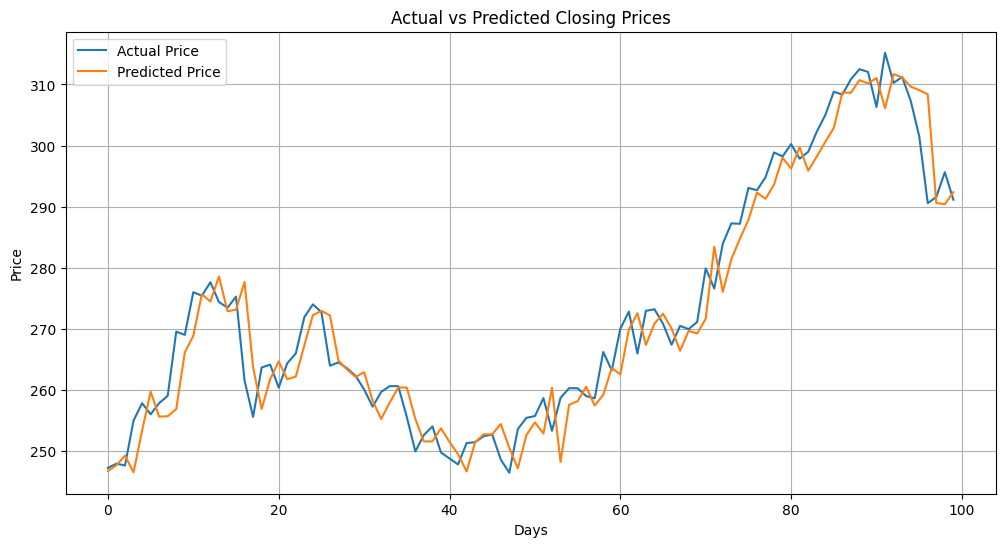

In [10]:
#Plot Actual vs Predicted Prices

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()